# 03 Experiments (CP1)

Сравнение baseline и одной экспериментальной модели на одинаковом split (`train/val/test`).

Приоритет метрики: **Macro-F1**.

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

In [2]:
ROOT = Path.cwd()
if not (ROOT / 'src' / 'modeling.py').exists():
    ROOT = ROOT.parent

sys.path.append(str(ROOT))

from src.modeling import run_cp1_experiments

In [3]:
output = run_cp1_experiments(
    processed_dir=ROOT / 'data' / 'processed',
    models_dir=ROOT / 'models',
    random_state=42,
)

results_df = output['results_df'].copy()
results_df

,model_id,model_name,feature_set,num_features,macro_f1_val,weighted_f1_val,accuracy_val,note
0,random_forest_exp,RandomForestClassifier,with_engineering,12,0.975758,0.979026,0.979133,Lightweight CP1 experiment with a tree model.
1,baseline_logreg,LogisticRegression,base,8,0.950756,0.956774,0.957133,CP1 baseline without using engineered features.


In [4]:
print('Best model:')
print(f"  id: {output['best_model_id']}")
print(f"  name: {output['best_model_name']}")
print(f"  feature set: {output['best_feature_set']}")

print('\nValidation metrics (best):')
for k, v in output['best_val_metrics'].items():
    print(f'  {k}: {v:.4f}')

print('\nTest metrics (best):')
for k, v in output['best_test_metrics'].items():
    print(f'  {k}: {v:.4f}')

Best model:
  id: random_forest_exp
  name: RandomForestClassifier
  feature set: with_engineering

Validation metrics (best):
  macro_f1: 0.9758
  weighted_f1: 0.9790
  accuracy: 0.9791

Test metrics (best):
  macro_f1: 0.9747
  weighted_f1: 0.9781
  accuracy: 0.9783


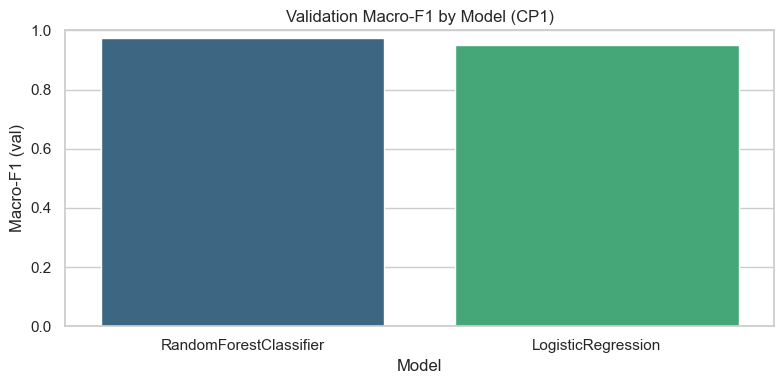

In [5]:
plot_df = results_df.sort_values('macro_f1_val', ascending=False).reset_index(drop=True)
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x='model_name', y='macro_f1_val', palette='viridis', hue='model_name', legend=False)
plt.title('Validation Macro-F1 by Model (CP1)')
plt.xlabel('Model')
plt.ylabel('Macro-F1 (val)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [6]:
results_path = Path(output['artifacts']['results_path'])
metrics_path = Path(output['artifacts']['metrics_path'])

saved_results = pd.read_csv(results_path)
saved_results

,model_id,model_name,feature_set,num_features,macro_f1_val,weighted_f1_val,accuracy_val,note
0,random_forest_exp,RandomForestClassifier,with_engineering,12,0.975758,0.979026,0.979133,Lightweight CP1 experiment with a tree model.
1,baseline_logreg,LogisticRegression,base,8,0.950756,0.956774,0.957133,CP1 baseline without using engineered features.


In [7]:
with open(output['artifacts']['metrics_path'], 'r', encoding='utf-8') as f:
    metrics_json = json.load(f)

metrics_json['best_model']

{'model_id': 'random_forest_exp',
 'model_name': 'RandomForestClassifier',
 'feature_set': 'with_engineering',
 'features': ['alpha',
  'delta',
  'u',
  'g',
  'r',
  'i',
  'z',
  'redshift',
  'u_g',
  'g_r',
  'r_i',
  'i_z']}

## Вывод

В CP1 экспериментальная модель `RandomForestClassifier` с инженерными признаками (`u_g`, `g_r`, `r_i`, `i_z`) улучшила качество относительно baseline:  
- `val`: Macro-F1 = 0.9758, Accuracy = 0.9791  
- `test`: Macro-F1 = 0.9747, Accuracy = 0.9783

Прирост по Macro-F1 относительно baseline составляет примерно +0.025 на `val` и +0.023 на `test`, что подтверждает полезность feature engineering уже на этапе CP1. Разница между `val` и `test` небольшая, значит модель обобщает стабильно и подходит как текущая лучшая модель.
